## Artist Analysis

In [3]:
%run prepare.ipynb
import matplotlib.pyplot as plt
def show(title):
  plt.savefig(f'img/{title}.svg', bbox_inches='tight')
  plt.savefig(f'img/{title}.png', bbox_inches='tight', dpi=300)
  plt.show()

### Artist Counts

In [15]:
dated_artists = dated_streams.groupby(dated_streams['artist']).agg({'uri': 'count'})
print(len(dated_artists), len(dated_artists[dated_artists['uri'] >= 10]))

print(dated_streams.pivot_table(
  index=['date'],
  values=['artist'],
  aggfunc={'artist': 'nunique'}
).mean()['artist'])

dated_artists = dated_streams.pivot_table(
  index=['artist'],
  values=['uri'],
  aggfunc={'uri': 'nunique'}
)
len(dated_artists[dated_artists['uri'] >= 10])

367 74
10.039274924471298


39

### Top Artists

In [118]:
top_artists["percent"] = top_artists["date"] / 319 # 319 days streamed - from time.ipynb
top_artists.head(10).reset_index()

,artist,date,ms_played,track,uri,h,percent
0,Ariana Grande,173,119486629,74,708,33.2,0.542320
1,Lorde,91,76632885,50,446,21.3,0.285266
2,Ethel Cain,83,68684207,23,200,19.1,0.260188
3,Sabrina Carpenter,164,53071262,45,343,14.7,0.514107
4,"Tyler, The Creator",85,51736918,51,260,14.4,0.266458
5,Taylor Swift,93,51478022,122,282,14.3,0.291536
6,Ryan Beatty,45,47597959,39,236,13.2,0.141066
7,Lucy Dacus,96,40820437,30,226,11.3,0.300940
8,Addison Rae,93,39260875,12,253,10.9,0.291536
9,grentperez,48,36447208,33,207,10.1,0.150470


### Top Tracks for Top Artists

In [134]:
mask = (dated_streams["artist"].isin(top_artists.head(5).index)) & (dated_streams['reason_start'] != "appload")
top_five = dated_streams[mask].pivot_table(
    index=['artist','track'],
    values=['uri'],
    aggfunc={'uri': 'count'}
).sort_values(by='uri',ascending=False)

top_five = top_five.groupby('artist').apply(lambda x: x.nlargest(5, 'uri'))
top_five.index.set_names(['artist', 'x', 'track'], inplace=True)
top_five.reset_index()[['artist', 'track', 'uri']]

,artist,track,uri
0,Ariana Grande,twilight zone,53
1,Ariana Grande,Hampstead,51
2,Ariana Grande,dandelion,51
3,Ariana Grande,Greedy,44
4,Ariana Grande,intro (end of the world) - extended,28
5,Ethel Cain,Nettles,83
6,Ethel Cain,American Teenager,21
7,Ethel Cain,Sun Bleached Flies,13
8,Ethel Cain,Tempest,10
9,Ethel Cain,Crush,6


In [6]:
colors = {
    'Ariana Grande': '#fbe',
    'Tyler, The Creator': '#4a6',
    'Lorde': '#ff8',
    'Ryan Beatty': '#7be',
    'Sabrina Carpenter': '#f77',
    'Taylor Swift': '#fc7',
    'Ethel Cain': '#bc9',
    'Lucy Dacus': '#67f',
    'grentperez': '#886',
  # 'ROLE MODEL': '#886',
    'Addison Rae': '#6bb',
  # 'Cynthia Erivo': '#ad9'
} 

### Top Artists by Month

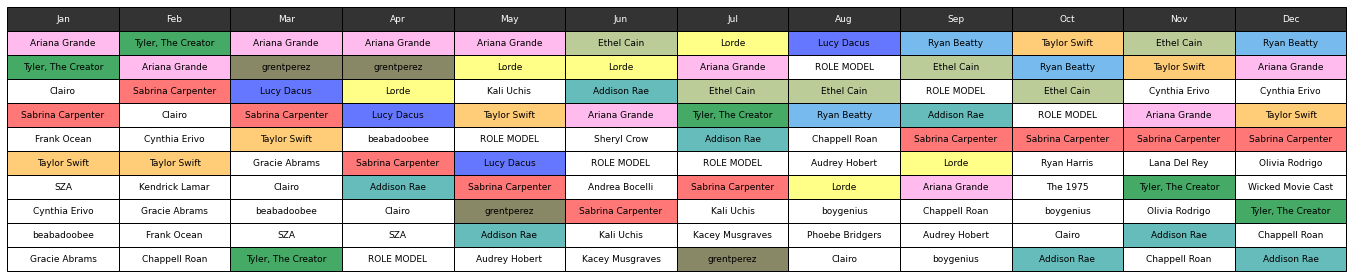

In [20]:
monthly_top_artists = monthly_top_artists[[col for col in monthly_top_artists if col.year == int(YEAR)]].head(10)

fig, ax = plt.subplots(figsize=(12, 4))

table = ax.table(cellText=monthly_top_artists.values, colLabels=dated_months.strftime('%b'), loc='center', cellLoc='center')
table.scale(2,2)

fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

for (row, col), cell in table.get_celld().items():
  if row == 0:
    cell.set_facecolor('#333')
    cell.get_text().set_color('white')
  elif monthly_top_artists.iloc[row-1,col] in colors:
    cell.set_facecolor(colors[monthly_top_artists.iloc[row-1,col]])
# plt.savefig('img/monthly_top_artists.svg', bbox_inches='tight')
# plt.show()
show('monthly_top_artists')

### Top Artist Line Chart

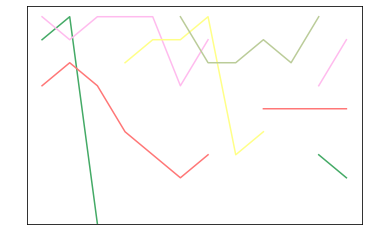

In [59]:
top_artists_pos[top_artists_pos > 10] = np.nan

fig, ax = plt.subplots()

top_5_pos = top_artists_pos[top_artists_pos.index.isin(top_artists.head(5).index)]
for x, row in top_5_pos.iterrows():
  ax.plot(row.index, 10-row, label=row.name, color=colors[row.name])

ax.set_xticks(top_5_pos.columns.tolist(), dated_months.strftime('%b'), color='white')
ax.set_facecolor("none")
ax.set_yticks(range(10), range(10, 0, -1), color='white')
ax.set_ylim(bottom=0)
ax.tick_params(axis='both', color='white')

# plt.legend(bbox_to_anchor=(1.04, 1), facecolor='black', labelcolor='white')
show('top_5_artist_positions')

### Top Artists as Share of Total Streaming Time

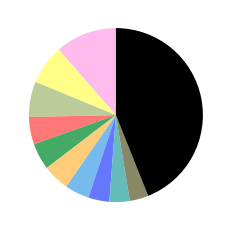

In [7]:
tas = top_artists.head(10)['ms_played']
other = top_artists[10:].sum()['ms_played']
tas['Other'] = other

plt.pie(tas, 
        # labels=tas.index, 
        colors=[colors.get(a, 'black') for a in tas.index], 
        startangle=90, counterclock=True)
show('top_10_artist_pie')

### Ratio of Days Streaming Each Top Artist

In [125]:
top_artists.head(5)['date'] / 319 #days_streamed

artist
Ariana Grande         0.542320
Lorde                 0.285266
Ethel Cain            0.260188
Sabrina Carpenter     0.514107
Tyler, The Creator    0.266458
Name: date, dtype: float64

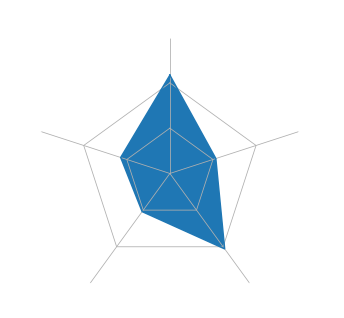

In [78]:
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_varsx, frame='polygon'):
    theta = np.linspace(0, 2*np.pi, 5, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
      def transform_path_non_affine(self, path):
        if path._interpolation_steps > 1: path = path.interpolated(5)
        return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
          super().__init__(*args, **kwargs)
          self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
          return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
          lines = super().plot(*args, **kwargs)
          for line in lines:
            x, y = line.get_data()
            if x[0] != x[-1]:
              x = np.concatenate((x, [x[0]]))
              y = np.concatenate((y, [y[0]]))
              line.set_data(x, y)

        def set_varlabels(self, labels):
          self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
          return RegularPolygon((0.5, 0.5), 5, radius=0.5, edgecolor="k")

        def draw(self, renderer):
          gridlines = self.yaxis.get_gridlines()
          for gl in gridlines:
            gl.get_path()._interpolation_steps = 5
          super().draw(renderer)

        def _gen_axes_spines(self):
          spine = Spine(axes=self, spine_type='circle', path=Path.unit_regular_polygon(5))
          spine.set_transform(Affine2D().scale(.5).translate(.5, .5) + self.transAxes)
          return {'polar': spine}
    register_projection(RadarAxes)
    return theta

theta = radar_factory(5, frame='polygon')                                     

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(projection='radar'))
ax.set_rgrids([0, 0.25, 0.5], labels=[])

d = top_artists.head(5)['date'] / 319
line = ax.plot(theta, d)
ax.fill(theta, d, alpha=1, label='_nolegend_')
ax.set_varlabels(top_artists.head(5).index.str.replace(' ', '\n'))
for l in ax.get_xticklabels(): l.set_color('white')
ax.set_rlim(0, 0.75)
ax.set_facecolor("none")

ax.tick_params(pad=10)
ax.spines['polar'].set_edgecolor('white')

show('top_5_artist_radar')


### Concert Analysis

In [127]:
concerts_2025 = [
  "mac demarco victoria", "lorde seattle",
  "peach pit victoria", "tyler vancouver",
  "beach boys victoria", "beabadoobee vancouver"
]

playlists = []
with open('json/Playlist1.json', 'r') as file:
  playlists = json.load(file)["playlists"]

playlists = [p for p in playlists if p["name"] in concerts_2025]

[('concerts', len(concerts_2025)), ('live songs', sum(len(p["items"]) for p in playlists)),
 ('artists', [" ".join(s.split()[:-1]) for s in concerts_2025])]


[('concerts', 6),
 ('live songs', 173),
 ('artists',
  ['mac demarco', 'lorde', 'peach pit', 'tyler', 'beach boys', 'beabadoobee'])]

### Consecutive Streaming Days

In [128]:
dated_streams['date'] = pd.to_datetime(dated_streams['date'])
daily_streams = dated_streams.pivot_table(
  index=['artist', 'date'],
  values=['uri'],
  aggfunc={'uri': 'count'}
).sort_values(by=['artist', 'date']).reset_index()

daily_streams.to_csv('x.csv')

streaks = {}
for artist, date in zip(daily_streams['artist'], daily_streams['date']):
  if (artist not in streaks): streaks[artist] = {}

  yesterday = date - pd.Timedelta(days=1)
  if (yesterday in streaks[artist]):
    streaks[artist][date] = streaks[artist][yesterday] + 1
  else:
    streaks[artist][date] = 1

reformed_data = [
  [outer_key, inner_key, value]
  for outer_key, inner_dict in streaks.items()
  for inner_key, value in inner_dict.items()
]

streaks = pd.DataFrame(reformed_data, columns=['artist', 'date', 'streak']).sort_values(by='streak', ascending=False)
streaks = streaks[streaks['streak'] > 5]
streaks.drop_duplicates(subset='artist', keep='first', inplace=True)

streaks['end'] = pd.to_datetime(streaks['date'])
streaks['start'] = streaks['end'] - pd.to_timedelta(streaks['streak'] - 1, unit='d') #+ pd.Timedelta(days=1)
streaks[['artist', 'streak', 'start', 'end']]

,artist,streak,start,end
286,Ariana Grande,12,2025-11-24,2025-12-05
2044,Olivia Rodrigo,8,2025-11-28,2025-12-05
2444,SZA,7,2025-04-03,2025-04-09
848,Ethel Cain,7,2025-06-20,2025-06-26
2269,ROLE MODEL,7,2025-08-18,2025-08-24
1665,Lorde,7,2025-06-26,2025-07-02
2626,Sabrina Carpenter,7,2025-11-28,2025-12-04
1785,Lucy Dacus,7,2025-08-23,2025-08-29
2846,Taylor Swift,6,2025-11-28,2025-12-03
22,Addison Rae,6,2025-04-21,2025-04-26
